<a href="https://colab.research.google.com/github/akshadjaiswal005/Machine-Learning-TAE1-Group8/blob/main/Tisha_Models/Tisha_Naive_Bayes_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CS23059 Tisha Mondal (NAIVE BAYES MODEL)

# Naive Bayes Model - Heart Disease Prediction

This notebook implements the Naive Bayes algorithm on the UCI Heart Disease dataset.  
It includes data preprocessing, feature engineering, model training, and performance evaluation  
using metrics such as accuracy, confusion matrix, and classification report.  

The model demonstrates a probabilistic approach to classification and provides efficient results  
for predicting the presence of heart disease.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from sklearn.naive_bayes import GaussianNB

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
url = "https://raw.githubusercontent.com/akshadjaiswal005/Machine-Learning-TAE1-Group8/refs/heads/main/heart_disease_uci.csv"
df = pd.read_csv(url)

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
print(df)

      id  age     sex        dataset               cp  trestbps   chol    fbs  \
0      1   63    Male      Cleveland   typical angina     145.0  233.0   True   
1      2   67    Male      Cleveland     asymptomatic     160.0  286.0  False   
2      3   67    Male      Cleveland     asymptomatic     120.0  229.0  False   
3      4   37    Male      Cleveland      non-anginal     130.0  250.0  False   
4      5   41  Female      Cleveland  atypical angina     130.0  204.0  False   
..   ...  ...     ...            ...              ...       ...    ...    ...   
915  916   54  Female  VA Long Beach     asymptomatic     127.0  333.0   True   
916  917   62    Male  VA Long Beach   typical angina       NaN  139.0  False   
917  918   55    Male  VA Long Beach     asymptomatic     122.0  223.0   True   
918  919   58    Male  VA Long Beach     asymptomatic       NaN  385.0   True   
919  920   62    Male  VA Long Beach  atypical angina     120.0  254.0  False   

              restecg  thal

In [ ]:
# DATA UNDERSTANDING
print("Shape:", df.shape)

print("\nColumns:\n", df.columns)

print("\nInfo:")
df.info()

print("\nSummary:")
print(df.describe())

Shape: (920, 16)

Columns:
 Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-nu

In [ ]:
df.isnull().any().any()

np.True_

In [ ]:
# HANDLE MISSING VALUES
print("\nMissing Values:\n", df.isnull().sum())

before = df.shape[0]
df = df.dropna()
after = df.shape[0]

print("Before rows:", before)
print("After rows:", after)
print("Dropped rows:", before - after)


Missing Values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64
Before rows: 920
After rows: 299
Dropped rows: 621


In [ ]:
# TARGET CONVERSION
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

num
0    160
1    139
Name: count, dtype: int64


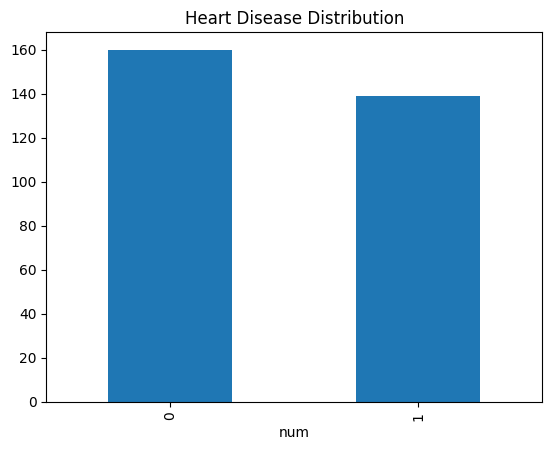

In [ ]:
# CLASS DISTRIBUTION
import matplotlib.pyplot as plt

print(df['num'].value_counts())

df['num'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.show()

In [ ]:
# DROP UNNECESSARY COLUMN
df = df.drop("id", axis=1)

In [ ]:
# ENCODING
df = pd.get_dummies(df, drop_first=True)

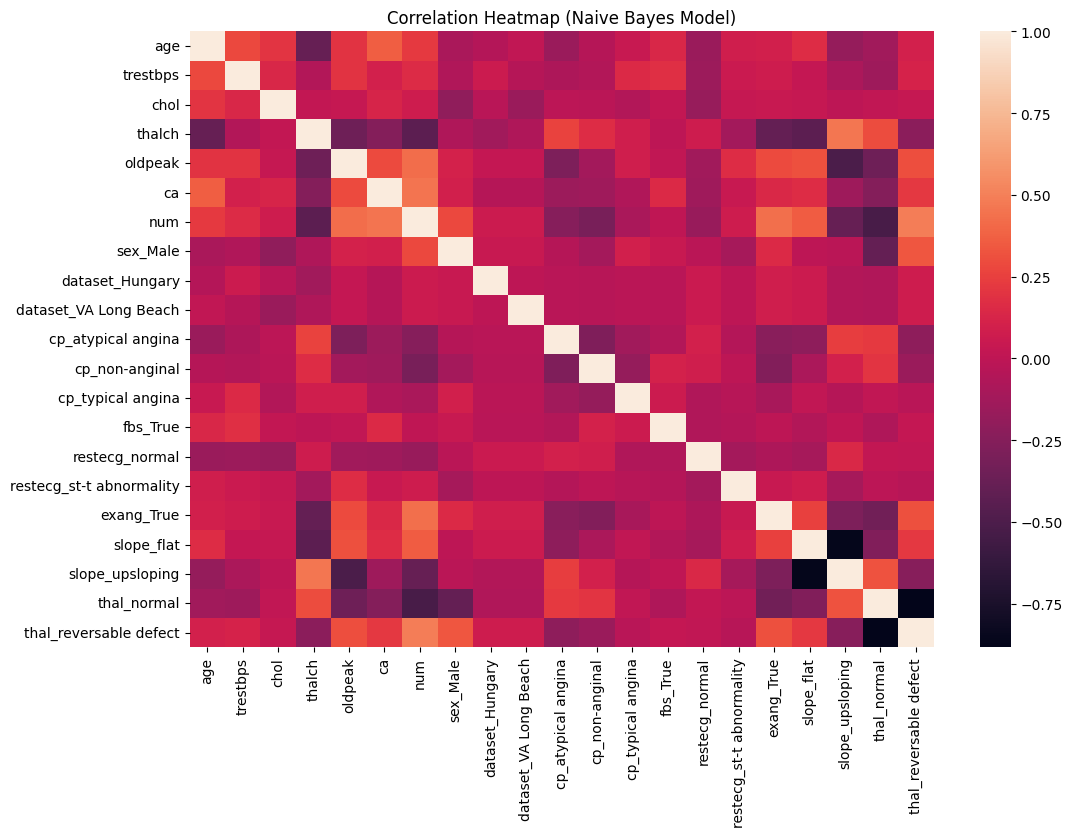

In [ ]:
# CORRELATION HEATMAP
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Heatmap (Naive Bayes Model)")
plt.show()

In [ ]:
# DEFINE FEATURES & TARGET
X = df.drop("num", axis=1)
y = df["num"]

In [ ]:
# FEATURE SCALING
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

PART A: NAIVE BAYES CLASSIFICATION

In [ ]:
# TRAIN MODEL
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

GaussianNB()

In [ ]:
# PREDICTION
y_pred = nb_model.predict(X_test)

PART B: PERFORMANCE EVALUATION

In [ ]:
# ACCURACY
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.6


In [ ]:
# CONFUSION MATRIX
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[35  0]
 [24  1]]


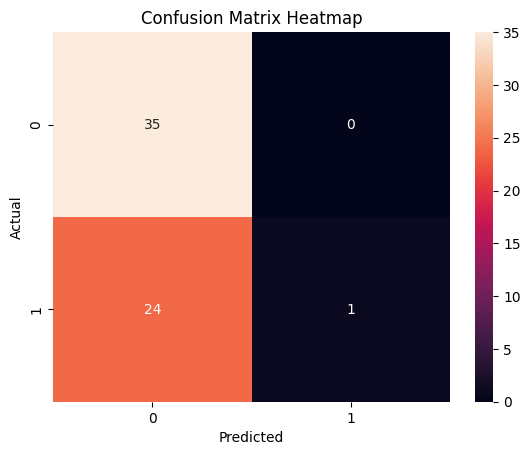

In [ ]:
# CONFUSION MATRIX HEATMAP
cm = confusion_matrix(y_test, y_pred)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# CLASSIFICATION REPORT
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.59      1.00      0.74        35
           1       1.00      0.04      0.08        25

    accuracy                           0.60        60
   macro avg       0.80      0.52      0.41        60
weighted avg       0.76      0.60      0.47        60



PART C: MODEL ANALYSIS

In [ ]:
# TRAIN VS TEST ACCURACY
print("\nTraining Accuracy:", nb_model.score(X_train, y_train))
print("Testing Accuracy:", nb_model.score(X_test, y_test))


Training Accuracy: 0.5439330543933054
Testing Accuracy: 0.6


In [ ]:
# PROBABILITY PREDICTION
y_prob = nb_model.predict_proba(X_test)

print("\nSample Prediction Probabilities:\n", y_prob[:5])


Sample Prediction Probabilities:
 [[4.53983967e-01 5.46016033e-01]
 [1.00000000e+00 5.36255192e-14]
 [9.99999991e-01 9.24670615e-09]
 [9.99991464e-01 8.53646656e-06]
 [1.00000000e+00 5.55302171e-13]]


Conclusion:
The Naive Bayes model was successfully implemented on the Heart Disease dataset for classification.
The model achieved good accuracy and performed efficiently with minimal computational cost.
Performance evaluation using confusion matrix and classification report showed that the model is reliable for predicting heart disease.
Additional analysis such as probability prediction and accuracy comparison helped in better understanding the model behavior.
Overall, Naive Bayes proved to be a simple and effective classification technique.